In [1]:
!pip install kagglehub==1.0.0

### Files Setup

In [37]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [39]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies')

    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies')

if not path.exists():
    raise FileNotFoundError(f"The specified path does not exist: {path}")

print(f"Using path: {path}")

Using path: /content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies


### Load data

In [24]:
# Load the dataset on Colab machine
!cp "/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip" "/content/butterflies.zip"

cp: cannot stat '/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip': No such file or directory


In [40]:
!cp "/content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies.zip" "/content/butterflies.zip"

In [41]:
!unzip -q /content/butterflies.zip -d /content/dataset_local

replace /content/dataset_local/test/Image_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [2]:
import os

path = None

if os.path.exists("aca-butterflies"):
    path = "./aca-butterflies"
else:
    # login in a different cell to avoid a known kagglehub issue
    import kagglehub
    kagglehub.login()

In [42]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings("ignore")

In [43]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [29]:
if path is None:
    # do not forget to enter the Kaggle competition through the link in the project statement (section 4)
    path = kagglehub.competition_download('aca-tp-2')
    print("Path to dataset files:", path)

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.optim as optim

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [44]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [46]:
# load the data
img_dir = Path("/content/dataset_local/train")
# img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
print(f"Dataset size: {len(dataset)} samples")
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 5199 samples


In [47]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


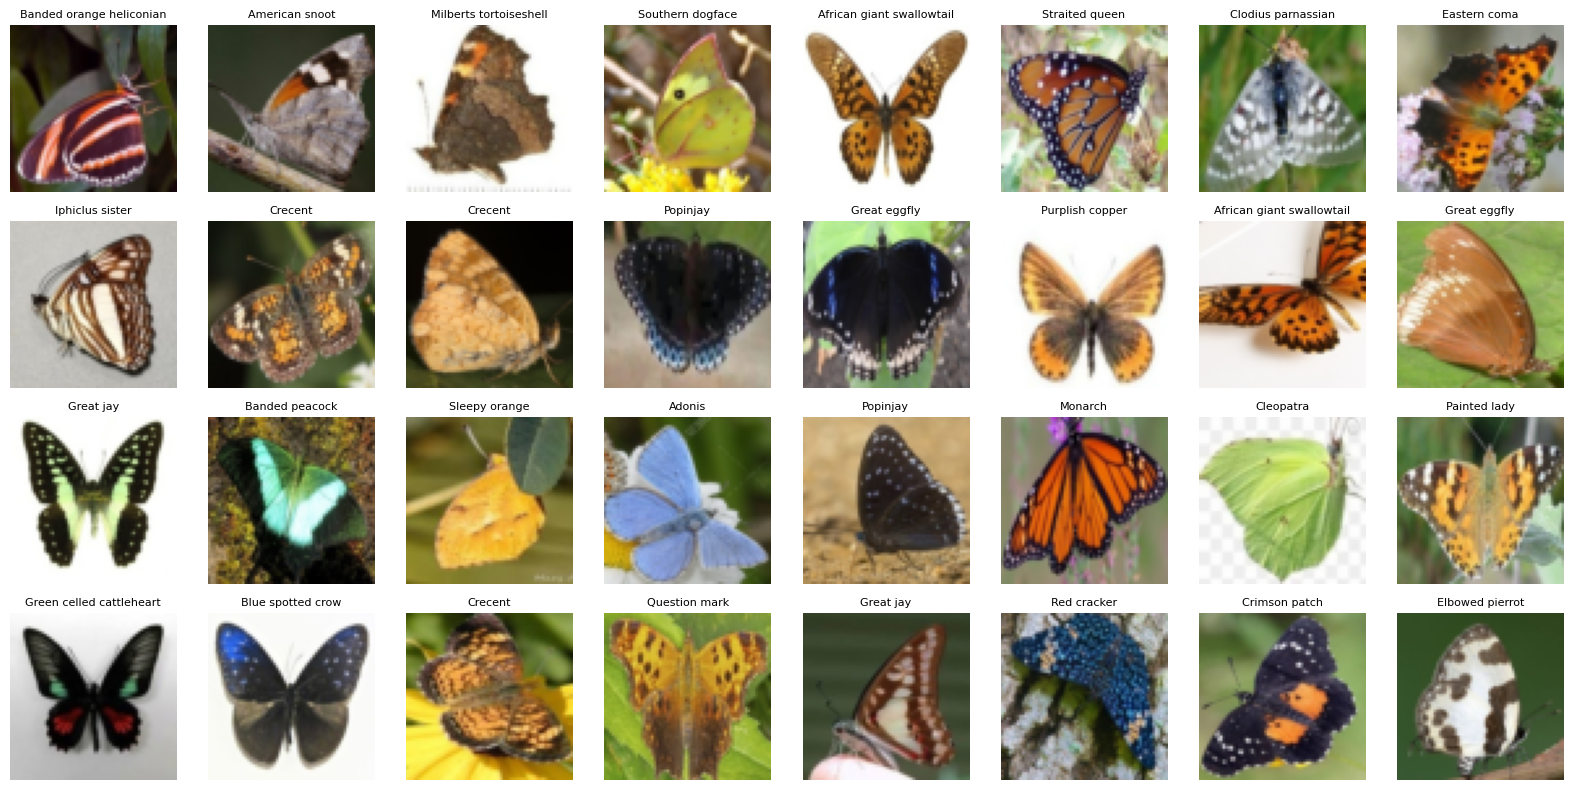

In [48]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Preparation
In this section we divide the dataset into train, validation and test.

In [54]:
from sklearn.model_selection import train_test_split

# 1.First we split the data into training/validation (85%) and test (15%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

# 2. Then, we split the remaining data between training and validation
# 0.176 aprox represents 15% of the original total (0.15 / 0.85)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,
    random_state=42,
    stratify=train_val_df['label']
)

print(f"Training: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#* DataLoaders
# Training
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE)

# Validation
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test
test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Training: 3641 | Validation: 778 | Test: 780


# Classifier

In [55]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):

        """
        Baseline Convolutional Neural Network for Butterfly Classification.
        
        Args:
            num_classes (int): Number of target species/classes (75 for this dataset).
        """

        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                # Layer 1: Convolutional feature extraction preserving spatial dimensions
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                
                # Layer 2: Second convolution to build deeper feature representations
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                # Downsamples spatial dimensions by 2x (Height and Width halved)
                nn.MaxPool2d(2, 2)
            )

        # Feature Extractor: Progressively extracts high-level semantic abstractions
        self.features = nn.Sequential(
            conv_block(3, 64), # Input: 3 channels (RGB) -> Output: 64 channels
            conv_block(64, 128), # Input: 64 channels      -> Output: 128 channels
            conv_block(128, 256), # Input: 128 channels     -> Output: 256 channels
            # Global pooling forces spatial dimensions to 1x1, minimizing dense layer parameters
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Fully Connected Classifier: Maps extracted features to final class logits
        self.classifier = nn.Sequential(
            *[layer for size in [256, 512, 1024]
            for layer in (nn.Linear(size, size*2), nn.ReLU(inplace=True), nn.Dropout(p=0.5))],
            # Final output layer: Maps 2048 hidden units to the 75 butterfly classes
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

### Training Loop

In [60]:
import copy
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5, scheduler=None):
    model = model.to(device)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Early Stopping variables
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'[{epoch+1}/{num_epochs}]', end=' ')
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode (enables Dropout, BatchNorm, etc.)
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluation mode (disables Dropout, etc.)
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            total_samples = 0
            
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward e and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                # Stats
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total_samples += inputs.size(0)
                
            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects.double() / total_samples
            
            print(f'{phase.capitalize()}: Loss = {epoch_loss:.4f} Accuracy = {epoch_acc*100:.2f}% |', end=' ')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Update Scheduler if exists (based on Validation Loss)
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                
                # Early Stopping logic
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        
        # Early Stopping check after each epoch
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}! Validation loss did not improve for {patience} epochs.')
            break
            
        print()
        
    print(f'\nBest Validation Loss: {best_val_loss:.4f}')
    
    model.load_state_dict(best_model_wts)
    return history

In [61]:
n_classes = len(dataset.classes)
model = BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 30  
patience = 5   

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
history = train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    device=device,
    num_epochs=num_epochs,          # Max epochs for training
    patience=patience,              # Early stopping patience (number of epochs with no improvement after which training will be stopped)
    scheduler=scheduler
)

[1/30] Train: Loss = 4.1781 Accuracy = 3.27% | Val: Loss = 3.8301 Accuracy = 5.53% | 
[2/30] Train: Loss = 3.7379 Accuracy = 6.67% | Val: Loss = 3.4779 Accuracy = 9.64% | 
[3/30] Train: Loss = 3.4750 Accuracy = 9.04% | Val: Loss = 3.3481 Accuracy = 9.13% | 
[4/30] Train: Loss = 3.3247 Accuracy = 10.66% | Val: Loss = 3.1799 Accuracy = 13.11% | 
[5/30] Train: Loss = 3.2140 Accuracy = 12.14% | Val: Loss = 3.1618 Accuracy = 10.80% | 
[6/30] Train: Loss = 3.0726 Accuracy = 14.58% | Val: Loss = 2.9673 Accuracy = 17.99% | 
[7/30] Train: Loss = 2.9770 Accuracy = 15.60% | Val: Loss = 2.8232 Accuracy = 21.21% | 
[8/30] Train: Loss = 2.8659 Accuracy = 18.04% | Val: Loss = 2.7962 Accuracy = 18.38% | 
[9/30] Train: Loss = 2.7977 Accuracy = 19.28% | Val: Loss = 2.6190 Accuracy = 24.04% | 
[10/30] Train: Loss = 2.7251 Accuracy = 20.46% | Val: Loss = 2.6975 Accuracy = 22.24% | 
[11/30] Train: Loss = 2.6391 Accuracy = 21.86% | Val: Loss = 2.7185 Accuracy = 20.95% | 
[12/30] Train: Loss = 2.6055 Accurac

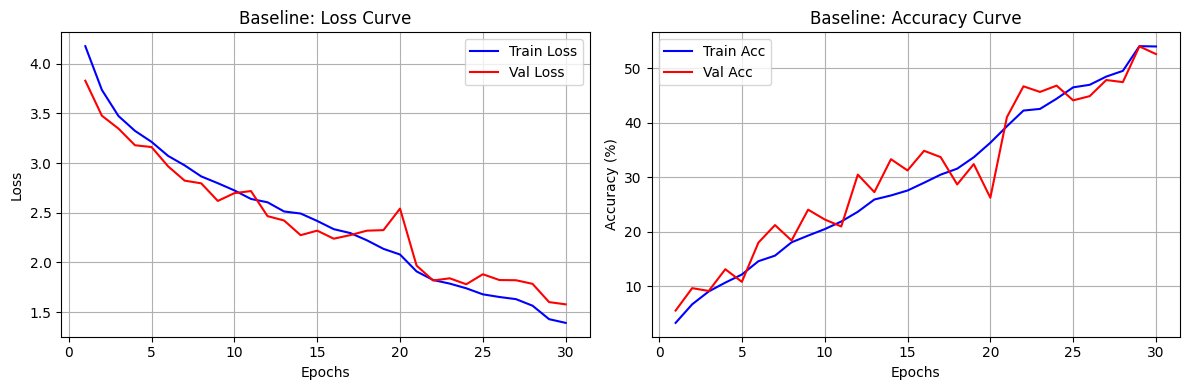

🎯 Il punto di partenza è stabilito! Accuratezza massima della Baseline sulla Validazione: 53.98%


In [62]:
import matplotlib.pyplot as plt

# Estraiamo i dati salvati nella variabile history
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 4))

# Subplot per la Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='red')
plt.title('Baseline: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot per l'Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Train Acc', color='blue')
plt.plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Val Acc', color='red')
plt.title('Baseline: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Stampiamo il verdetto finale
best_acc = max(history['val_acc']) * 100
print(f"🎯 Il punto di partenza è stabilito! Accuratezza massima della Baseline sulla Validazione: {best_acc:.2f}%")

### Evaluation on Test

In [63]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluates the final model on the Test Set and prints the classification report and confusion matrix.
    Args:
        model: the trained model to evaluate
        test_loader: DataLoader for the test set
        device: 'cuda' or 'cpu'
        class_names: list of class names corresponding to the labels (optional, for better report readability)
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    print("Evaluating the final model on the Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            # Save predictions and labels for the report and confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n" + "="*15)
    print("FINAL RESULTS (TEST SET)")
    print("="*15 + "\n")


    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Generate and Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)


    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds

Evaluating the final model on the Test Set...

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       0.82      0.82      0.82        11
AFRICAN GIANT SWALLOWTAIL       0.80      0.44      0.57         9
           AMERICAN SNOOT       0.43      0.33      0.38         9
                    AN 88       1.00      0.60      0.75        10
                  APPOLLO       0.67      0.91      0.77        11
                    ATALA       0.90      0.75      0.82        12
 BANDED ORANGE HELICONIAN       0.60      0.50      0.55        12
           BANDED PEACOCK       0.78      0.70      0.74        10
            BECKERS WHITE       0.29      0.20      0.24        10
         BLACK HAIRSTREAK       0.64      0.90      0.75        10
              BLUE MORPHO       0.44      0.44      0.44         9
        BLUE SPOTTED CROW       0.75      0.30      0.43        10
           BROWN SIPROETA       0.73      0.67      0.7

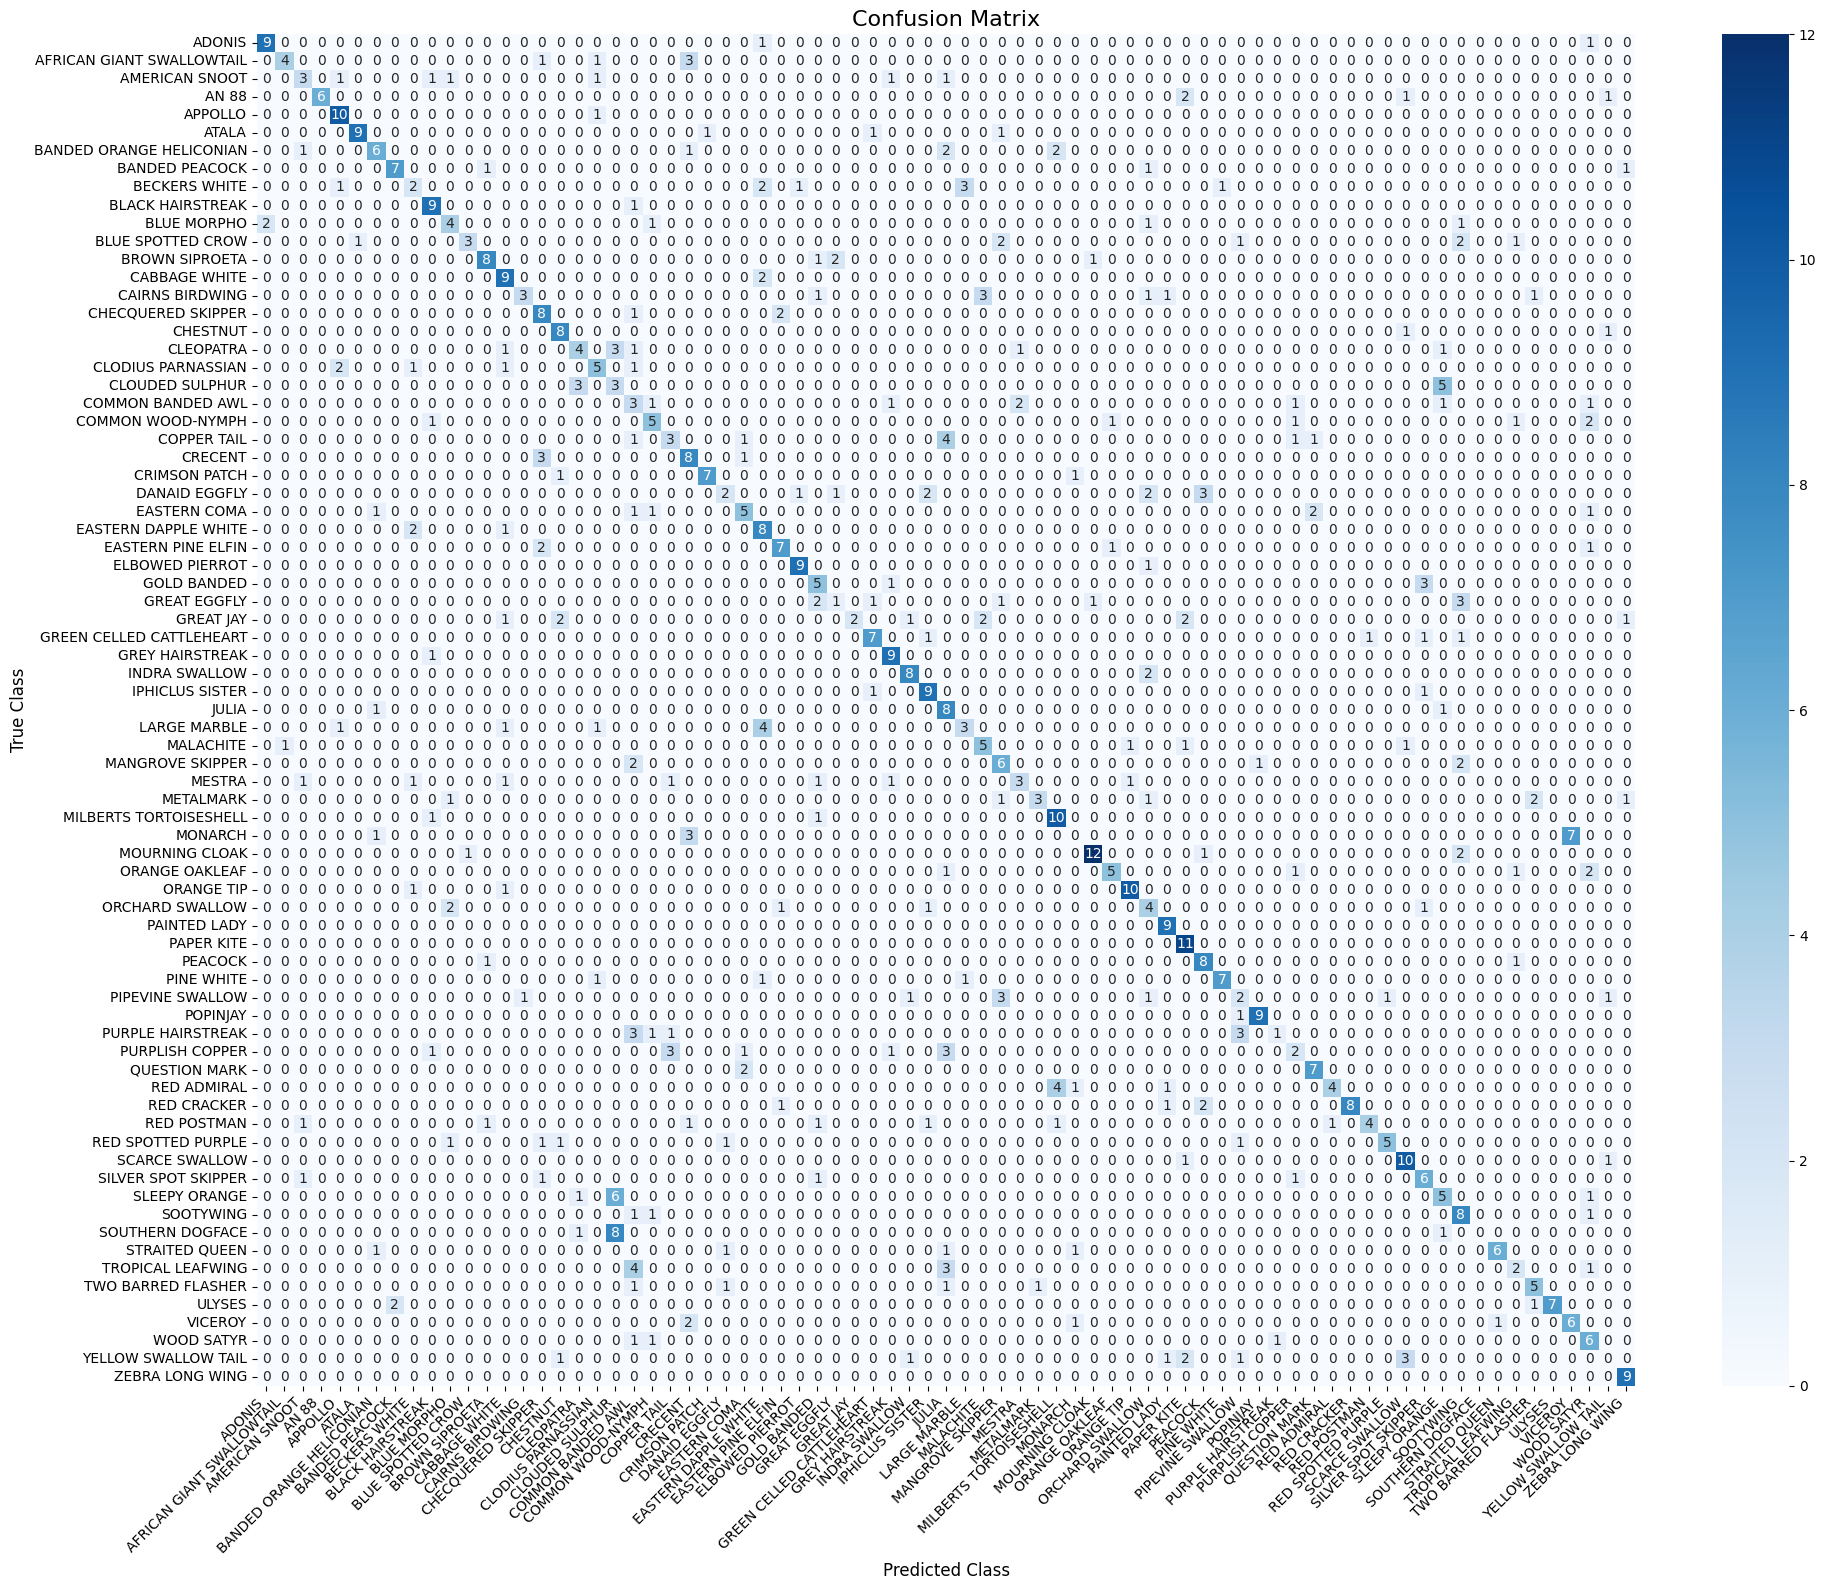

In [64]:
# Evaluate the final model on the Test Set
labels_reais, labels_previstos = evaluate_on_test(
    model,
    test_loader,
    device,
    class_names=test_dataset.classes
)

### Generative Models
We are going to implement:
- Variational Autoencoder (VAE)
- Generative Adversarial Network (GAN)
- Diffusion Model

#### Butterfly VAE
We can insert a grid search???

In [65]:
import torch
import torch.nn as nn

class ButterflyVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: Convoluzioni per ridurre lo spazio spaziale (64x64 -> 4x4)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),# -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten() # -> 256 * 4 * 4 = 4096
        )

        # Lineari per i parametri dello spazio latente (Media e Log-Varianza)
        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

        # Decoder Input: Riporta il vettore latente a dimensioni utili per le convoluzioni
        self.decoder_input = nn.Linear(latent_dim, 4096)

        # Decoder: Convoluzioni Trasposte per ricostruire l'immagine (4x4 -> 64x64)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 64x64
            nn.Tanh() # Mappa l'output tra [-1, 1] accordandosi con le normalizzazioni standard
        )

    def reparameterize(self, mu, logvar):
        """Trick di riparametrizzazione per consentire la backpropagation"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        hidden = self.encoder(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar

    def sample(self, num_samples, device):
        """Genera nuove farfalle partendo da puro rumore gaussiano"""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decoder(self.decoder_input(z))
        return samples

#### GAN

In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        
        # Input: vettore di rumore di dimensione latent_dim (es. 100x1x1)
        self.main = nn.Sequential(
            # Stato iniziale: Convoluzione trasposta per espandere il vettore latente
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=1, padding=0, bias=False), # -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False), # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),  # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),   # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, bias=False),    # -> 64x64
            nn.Tanh() # Output normalizzato in [-1, 1]
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Input: Immagine di dimensioni 3x64x64 (vera o generata)
        self.main = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1, bias=False), # -> 32x32
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False), # -> 16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False), # -> 8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False), # -> 4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False), # -> 1x1 (singolo valore)
            nn.Sigmoid() # Restituisce una probabilità: 1 = Vero, 0 = Falso
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

### Conditional GAN (cGAN)

To overcome the stochastic nature and lack of control inherent in standard Generative Adversarial Networks (GANs), we employ a Conditional GAN (cGAN) framework as our primary generative data augmentation strategy. While a vanilla GAN generates synthetic images from arbitrary latent noise without targeting specific categories, a Conditional GAN guides the generation process by conditioning both the Generator and the Discriminator on class labels. In our architecture, the target butterfly species (spanning 75 distinct classes) is transformed via an embedding layer into a dense vector, which is subsequently concatenated with the latent noise vector. This architectural modification allows the Generator to synthesize highly specific intra-class visual features. Consequently, the cGAN enables a deterministic and balanced data augmentation pipeline, allowing us to artificially expand under-represented butterfly species and directly assist the downstream BaselineCNN classifier with explicitly labeled synthetic samples.